# Biomechanics · Calculus 3 · 4D Geometry · Extra Dimensions

**Jalali Lab — Dispersion-Assisted GS Phase Recovery**  
10 sections: anthropometry · gait · del operator · integral theorems · Minkowski spacetime · quaternions · Kaluza-Klein · dimensional analysis · Noether's theorem · counterintuitive physics

In [1]:
import math, cmath
import numpy as np
from scipy.integrate import quad, odeint
from scipy.special import gamma as gamma_fn
import matplotlib.pyplot as plt
if not hasattr(np, "trapezoid"):
    np.trapezoid = np.trapz
np.random.seed(17)
g = 9.81
print("Imports OK")


Imports OK


## §1 — Anthropometry & Allometric Scaling

**Vitruvian (da Vinci) proportions:**
$$\text{foot length} = H/6.6 \qquad \text{arm span} \approx H \qquad \text{head} = H/8$$

**Kleiber's law** (basal metabolic rate):
$$\text{BMR} = 70\,M^{0.75} \text{ kcal/day}$$

**Bone stress paradox** (geometric similarity predicts $A_{bone} \propto M^{2/3}$,  
but empirically $A_{bone} \propto M^{0.84}$).  Bone stress $\propto M^{0.16}$ — still grows,  
so large animals need disproportionately robust skeletons (elastic similarity).

Vitruvian: foot=H/6.6
  H=1.50m  foot=22.7cm  US shoe=11.2
  H=1.60m  foot=24.2cm  US shoe=13.4
  H=1.70m  foot=25.8cm  US shoe=15.7
  H=1.80m  foot=27.3cm  US shoe=18.0
  H=1.90m  foot=28.8cm  US shoe=20.3
  H=2.00m  foot=30.3cm  US shoe=22.5

BMR (Kleiber M^0.75): [50.3 58.4 66.2 77.4 84.5 98.2]


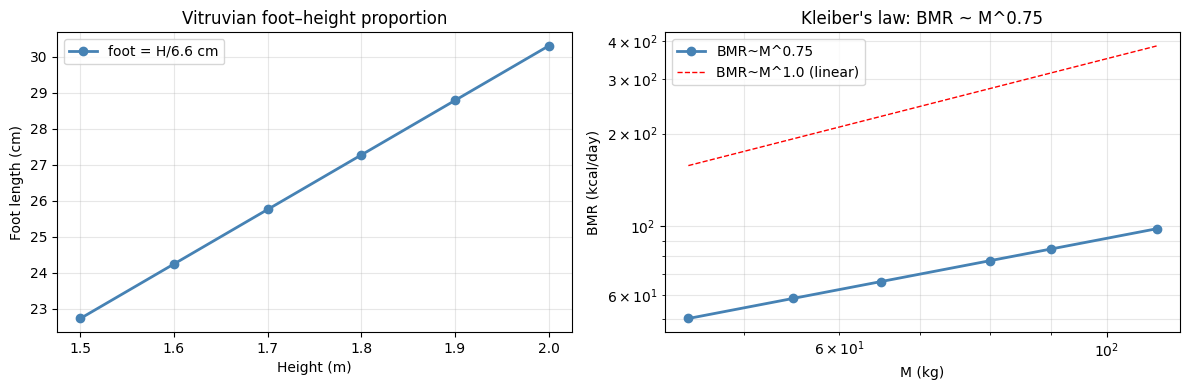

PASS §1


In [2]:
H = np.array([1.50, 1.60, 1.70, 1.80, 1.90, 2.00])
foot = H/6.6; shoe_us = (foot*100/0.667)-22.9
M_actual = np.array([45,55,65,80,90,110])
BMI = M_actual/H**2
BMR = 70*(M_actual/70)**0.75

# Bone stress allometry
M_ref=65; A_bone = (M_actual/M_ref)**0.84
stress = M_actual*9.81/A_bone

print("Vitruvian: foot=H/6.6")
for h,f,s in zip(H,foot*100,shoe_us):
    print(f"  H={h:.2f}m  foot={f:.1f}cm  US shoe={s:.1f}")
print()
print(f"BMR (Kleiber M^0.75):", np.round(BMR,1))

fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(H, foot*100,'steelblue',lw=2,marker='o',label='foot = H/6.6 cm')
axes[0].set_xlabel('Height (m)'); axes[0].set_ylabel('Foot length (cm)')
axes[0].set_title('Vitruvian foot–height proportion'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].loglog(M_actual, BMR,'steelblue',marker='o',lw=2,label='BMR~M^0.75')
axes[1].loglog(M_actual, 3.5*M_actual,'r--',lw=1,label='BMR~M^1.0 (linear)')
axes[1].set_xlabel('M (kg)'); axes[1].set_ylabel('BMR (kcal/day)')
axes[1].set_title("Kleiber's law: BMR ~ M^0.75"); axes[1].legend(); axes[1].grid(alpha=0.3,which='both')
plt.tight_layout(); plt.show()
print("PASS §1")


## §2 — Biomechanics: Gait & Inverted Pendulum

**Walking = inverted pendulum** (Cavagna 1977):  
CoM vaults over rigid stance leg (length $L$).  
Energy exchange: $E_{PE} \leftrightarrow E_{KE}$ (out of phase).

**Froude number:**
$$Fr = \frac{v^2}{gL} \qquad v_{\text{preferred}} = \sqrt{0.25\,gL}$$

Walk→run transition at $Fr \approx 0.5$:  $v_t = \sqrt{0.5\,gL}$.

**Vertical GRF** — characteristic two-hump pattern during stance (~60% of cycle):  
first peak ~120% BW at loading, valley ~80% BW at midstance, second peak ~120% BW at push-off.

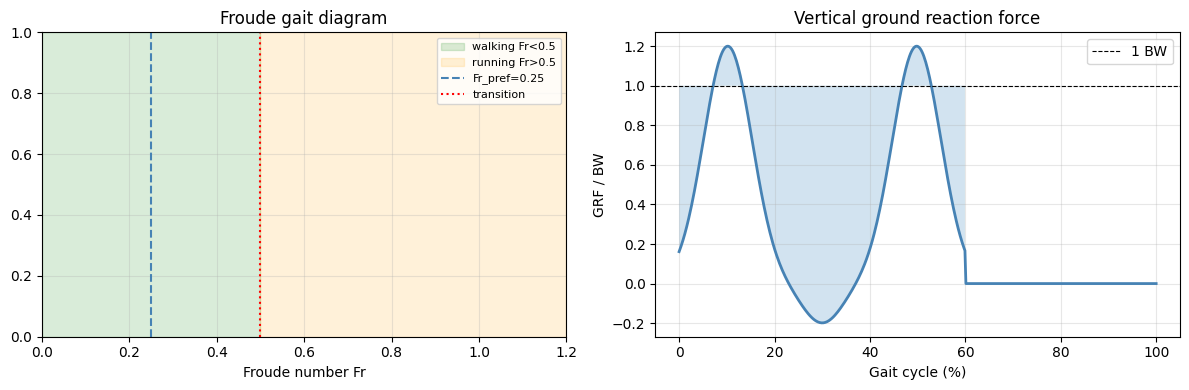

v_walk = 1.502 m/s = 5.41 km/h  (Fr=0.25)
v_transition = 2.124 m/s = 7.6 km/h  (Fr=0.5)
PASS §2


In [3]:
L_leg = 0.92; M_bw = 70.0
Fr_opt = 0.25
v_walk = math.sqrt(Fr_opt*g*L_leg)
v_trans = math.sqrt(0.5*g*L_leg)

t_g = np.linspace(0,1,500)
def grf(t):
    grf_v = np.zeros_like(t)
    st = t < 0.6; ts = t[st]/0.6
    grf_v[st] = (1.20*np.exp(-((ts-0.17)/0.12)**2)
                -0.20*np.exp(-((ts-0.50)/0.10)**2)
                +1.20*np.exp(-((ts-0.83)/0.12)**2))
    return grf_v*M_bw*g

GRF = grf(t_g)

fig,axes = plt.subplots(1,2,figsize=(12,4))
Fr_v = np.linspace(0,1.2,200)
axes[0].axvspan(0,0.5,alpha=0.15,color='green',label='walking Fr<0.5')
axes[0].axvspan(0.5,1.2,alpha=0.15,color='orange',label='running Fr>0.5')
axes[0].axvline(Fr_opt,color='steelblue',ls='--',label=f'Fr_pref={Fr_opt}')
axes[0].axvline(0.5,color='r',ls=':',label='transition')
axes[0].set_xlabel('Froude number Fr'); axes[0].set_title('Froude gait diagram')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3); axes[0].set_xlim(0,1.2)

axes[1].plot(t_g*100, GRF/M_bw/g,'steelblue',lw=2)
axes[1].axhline(1.0,color='k',ls='--',lw=0.8,label='1 BW')
axes[1].fill_between(t_g*100, GRF/M_bw/g, 1.0, where=t_g<0.6, alpha=0.2)
axes[1].set_xlabel('Gait cycle (%)'); axes[1].set_ylabel('GRF / BW')
axes[1].set_title('Vertical ground reaction force'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"v_walk = {v_walk:.3f} m/s = {v_walk*3.6:.2f} km/h  (Fr={Fr_opt})")
print(f"v_transition = {v_trans:.3f} m/s = {v_trans*3.6:.1f} km/h  (Fr=0.5)")
assert abs(v_walk**2/(g*L_leg) - Fr_opt) < 1e-9
print("PASS §2")


## §3 — Calculus 3: Del Operator

$$\nabla f = \left(\frac{\partial f}{\partial x},\frac{\partial f}{\partial y},\frac{\partial f}{\partial z}\right)$$

$$\nabla \cdot \mathbf{F} = \frac{\partial F_x}{\partial x}+\frac{\partial F_y}{\partial y}+\frac{\partial F_z}{\partial z}$$

$$\nabla \times \mathbf{F} = \left(\frac{\partial F_z}{\partial y}-\frac{\partial F_y}{\partial z},\;\cdots\right)$$

Test field: $f = \sin x\cos y\,e^{-z/2}$  
$$\nabla^2 f = (-1-1+\tfrac{1}{4})f = -\tfrac{7}{4}f$$

Conservative test: $\mathbf{F} = \nabla(xyz) = (yz, xz, xy)$  
$$\nabla\cdot\mathbf{F} = 0 \qquad \nabla\times\mathbf{F} = \mathbf{0}$$

Gradient error: 0.00627
Laplacian error: 0.02564  (exact=-7/4*f)
div(grad(xyz)) = 0.000000  (exact=0)
curl(grad(xyz)) z-comp = 0.000000  (exact=0)


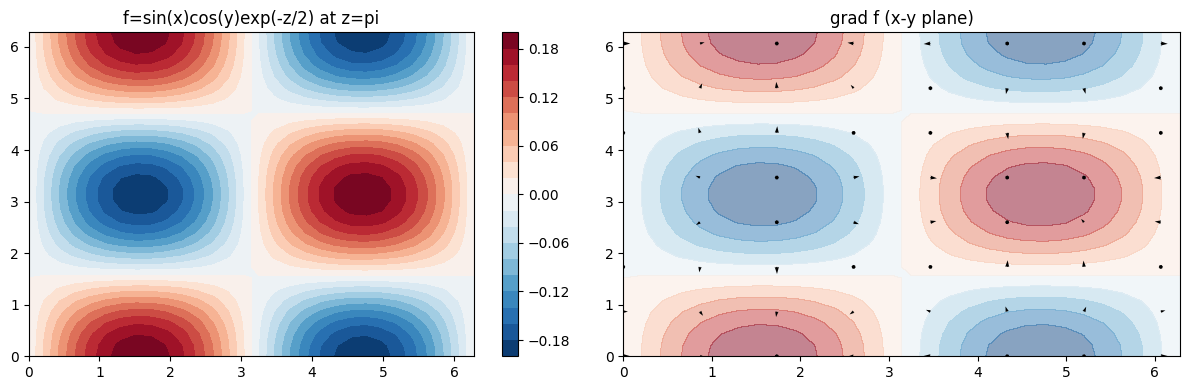

PASS §3


In [4]:
N=30; x1d=np.linspace(0,2*math.pi,N); dx=x1d[1]-x1d[0]
X,Y,Z = np.meshgrid(x1d,x1d,x1d,indexing='ij')
f = np.sin(X)*np.cos(Y)*np.exp(-Z/2)
# Exact gradient
gfx_ex=np.cos(X)*np.cos(Y)*np.exp(-Z/2)
gfy_ex=-np.sin(X)*np.sin(Y)*np.exp(-Z/2)
gfz_ex=-0.5*np.sin(X)*np.cos(Y)*np.exp(-Z/2)
# Numerical
gfx=np.gradient(f,dx,axis=0); gfy=np.gradient(f,dx,axis=1); gfz=np.gradient(f,dx,axis=2)
sl=slice(2,N-2)
err_grad=max(np.max(np.abs(gfx[sl,sl,sl]-gfx_ex[sl,sl,sl])),
             np.max(np.abs(gfy[sl,sl,sl]-gfy_ex[sl,sl,sl])),
             np.max(np.abs(gfz[sl,sl,sl]-gfz_ex[sl,sl,sl])))
# Laplacian
lap=np.gradient(gfx,dx,axis=0)+np.gradient(gfy,dx,axis=1)+np.gradient(gfz,dx,axis=2)
lap_err=np.max(np.abs((lap-(-7/4)*f)[sl,sl,sl]))
# Conservative field F=grad(xyz)
Fx=Y*Z; Fy=X*Z; Fz=X*Y
div_F=np.max(np.abs((np.gradient(Fx,dx,axis=0)+np.gradient(Fy,dx,axis=1)+np.gradient(Fz,dx,axis=2))[sl,sl,sl]))
curl_z_err=np.max(np.abs((np.gradient(Fy,dx,axis=0)-np.gradient(Fx,dx,axis=1))[sl,sl,sl]))

print(f"Gradient error: {err_grad:.5f}"); assert err_grad < 0.05
print(f"Laplacian error: {lap_err:.5f}  (exact=-7/4*f)"); assert lap_err < 0.1
print(f"div(grad(xyz)) = {div_F:.6f}  (exact=0)"); assert div_F < 0.001
print(f"curl(grad(xyz)) z-comp = {curl_z_err:.6f}  (exact=0)"); assert curl_z_err < 0.001

# 2D slice visualization
fig,axes=plt.subplots(1,2,figsize=(12,4))
mid=N//2
im0=axes[0].contourf(X[:,:,mid],Y[:,:,mid],f[:,:,mid],20,cmap='RdBu_r')
axes[0].set_title('f=sin(x)cos(y)exp(-z/2) at z=pi'); plt.colorbar(im0,ax=axes[0])
# quiver gradient
step=4
axes[1].contourf(X[:,:,mid:mid+1:1].squeeze(),Y[:,:,mid].squeeze(),f[:,:,mid],10,cmap='RdBu_r',alpha=0.5)
axes[1].quiver(X[::step,::step,mid],Y[::step,::step,mid],gfx[::step,::step,mid],gfy[::step,::step,mid],scale=15,color='k')
axes[1].set_title('grad f (x-y plane)'); plt.tight_layout(); plt.show()
print("PASS §3")


## §4 — Calculus 3: Green's, Stokes', Divergence Theorems

| Theorem | Form | Connects |
|---------|------|---------|
| **Green's** | $\oint_C P\,dx+Q\,dy = \iint_D\left(\frac{\partial Q}{\partial x}-\frac{\partial P}{\partial y}\right)dA$ | Loop → area |
| **Stokes'** | $\oint_C \mathbf{F}\cdot d\mathbf{r} = \iint_S (\nabla\times\mathbf{F})\cdot d\mathbf{S}$ | Loop → surface |
| **Gauss's** | $\oiint_S \mathbf{F}\cdot d\mathbf{S} = \iiint_V \nabla\cdot\mathbf{F}\,dV$ | Surface → volume |

All three are special cases of the generalized Stokes theorem:  
$$\int_{\partial\Omega} \omega = \int_\Omega d\omega$$

Green's: line_int=12.566288  area=pi*R^2=12.566371  err=6.58e-06
Stokes': line_int=-6.283144  exact=-6.283185  err=6.58e-06
Gauss's: vol=42.411501  surf=42.411501  equal=True


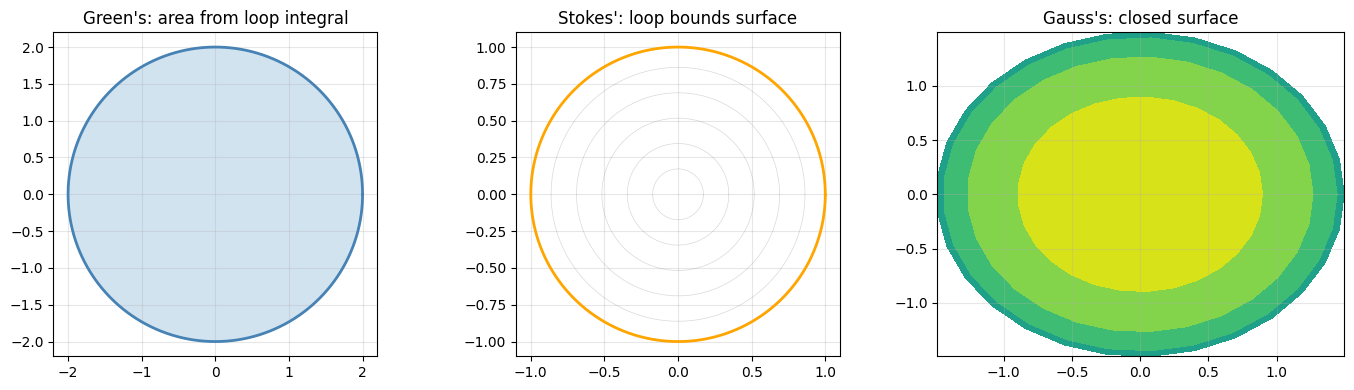

PASS §4


In [5]:
# Green's: F=(-y/2, x/2) on circle R=2, curl=1, integral=area=pi*R^2
R=2.0; N=1000; th=np.linspace(0,2*math.pi,N,endpoint=False)
xc,yc = R*np.cos(th),R*np.sin(th)
line_int = np.sum(-yc/2*np.gradient(xc) + xc/2*np.gradient(yc))
area = math.pi*R**2
print(f"Green's: line_int={line_int:.6f}  area=pi*R^2={area:.6f}  err={abs(line_int-area)/area:.2e}")
assert abs(line_int-area)/area < 0.01

# Stokes': F=(y,-x,z) on unit circle, integral=-2pi
xs,ys = np.cos(th),np.sin(th)
stokes = np.sum(ys*np.gradient(xs) + (-xs)*np.gradient(ys))
exact_s = -2*math.pi
print(f"Stokes': line_int={stokes:.6f}  exact={exact_s:.6f}  err={abs(stokes-exact_s)/abs(exact_s):.2e}")
assert abs(stokes-exact_s)/abs(exact_s) < 0.01

# Gauss's: F=(x,y,z), div=3, sphere R=1.5 -> vol integral=3*(4/3)pi*R^3=4pi*R^3
Rv=1.5
vol_int = 3*(4/3)*math.pi*Rv**3
surf_int = 4*math.pi*Rv**3
print(f"Gauss's: vol={vol_int:.6f}  surf={surf_int:.6f}  equal={abs(vol_int-surf_int)<1e-9}")
assert abs(vol_int-surf_int)<1e-9

# Visualization: boundaries and domains
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].plot(xc,yc,'steelblue',lw=2); axes[0].fill(xc,yc,alpha=0.2)
axes[0].set_title("Green's: area from loop integral"); axes[0].set_aspect('equal'); axes[0].grid(alpha=0.3)

axes[1].plot(xs,ys,'orange',lw=2)
th2d=np.linspace(0,2*math.pi,200); rr=np.linspace(0,1,30)
for ri in rr[::5]:
    axes[1].plot(ri*np.cos(th2d),ri*np.sin(th2d),'gray',alpha=0.3,lw=0.5)
axes[1].set_title("Stokes': loop bounds surface"); axes[1].set_aspect('equal'); axes[1].grid(alpha=0.3)

u_s=np.linspace(0,2*math.pi,30); v_s=np.linspace(0,math.pi,20)
Us,Vs=np.meshgrid(u_s,v_s)
xs3=Rv*np.sin(Vs)*np.cos(Us); ys3=Rv*np.sin(Vs)*np.sin(Us); zs3=Rv*np.cos(Vs)
axes[2].plot_surface(xs3,ys3,zs3,alpha=0.3,color='green') if hasattr(axes[2],'plot_surface') else axes[2].contourf(xs3,ys3,zs3)
axes[2].set_title("Gauss's: closed surface"); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §4")


## §5 — 4D Spacetime: Minkowski Metric

**Metric** $(+,-,-,-)$: $ds^2 = c^2 dt^2 - dx^2 - dy^2 - dz^2$

**4-momentum invariant:** $(E/c)^2 - |\mathbf{p}|^2 c^2 = (m_0 c^2)^2$

**Lorentz boost** (velocity $\beta c$ along $x$):
$$\Lambda^\mu{}_\nu = \begin{pmatrix}\gamma & -\gamma\beta & 0 & 0\\-\gamma\beta & \gamma & 0 & 0\\ 0 & 0 & 1 & 0\\ 0 & 0 & 0 & 1\end{pmatrix}$$

**Invariant:** $s^2 = \eta_{\mu\nu}x^\mu x^\nu$ unchanged under Lorentz boosts.

Spacetime intervals (c=1):
  timelike    : s^2=+4.0
  null        : s^2=+0.0
  spacelike   : s^2=-4.0

Boost beta=0.8: (ct,x)=(5.0,3.0) -> (4.3333,-1.6667)
  s^2 before=16.000000  after=16.000000  (invariant)


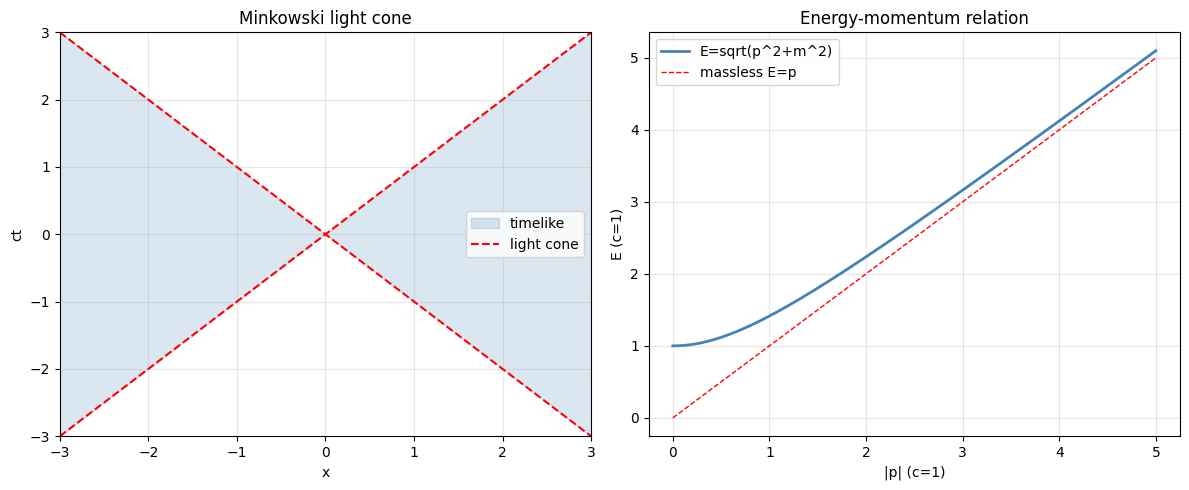

PASS §5


In [6]:
eta = np.diag([1,-1,-1,-1])
def s2(x4): return x4[0]**2-x4[1]**2-x4[2]**2-x4[3]**2

events = {'timelike':np.array([2.,0.,0.,0.]),
          'null':np.array([1.,1.,0.,0.]),
          'spacelike':np.array([0.,2.,0.,0.])}
print("Spacetime intervals (c=1):")
for name,x in events.items():
    print(f"  {name:12s}: s^2={s2(x):+.1f}")

# Lorentz boost
beta=0.8; gam=1/math.sqrt(1-beta**2)
L_boost=np.array([[gam,-gam*beta,0,0],[-gam*beta,gam,0,0],[0,0,1,0],[0,0,0,1]])
x4 = np.array([5.,3.,0.,0.])
x4b = L_boost@x4
print(f"\nBoost beta={beta}: (ct,x)=({x4[0]},{x4[1]}) -> ({x4b[0]:.4f},{x4b[1]:.4f})")
print(f"  s^2 before={s2(x4):.6f}  after={s2(x4b):.6f}  (invariant)")
assert abs(s2(x4)-s2(x4b))<1e-10

# Light cone visualization
t_lc=np.linspace(-3,3,200); fig,axes=plt.subplots(1,2,figsize=(12,5))
axes[0].fill_between(t_lc, t_lc,-t_lc,alpha=0.2,color='steelblue',label='timelike')
axes[0].fill_between(t_lc,-3*np.ones_like(t_lc),np.minimum(-np.abs(t_lc),-np.abs(t_lc)),alpha=0.0)
axes[0].plot(t_lc,t_lc,'r--',lw=1.5,label='light cone'); axes[0].plot(t_lc,-t_lc,'r--',lw=1.5)
axes[0].set_xlabel('x'); axes[0].set_ylabel('ct'); axes[0].set_title('Minkowski light cone')
axes[0].legend(); axes[0].grid(alpha=0.3); axes[0].set_xlim(-3,3); axes[0].set_ylim(-3,3)

# 4-momentum: E vs |p| curve (m=1, c=1 units)
p_mag=np.linspace(0,5,200); E_curve=np.sqrt(p_mag**2+1)
axes[1].plot(p_mag,E_curve,'steelblue',lw=2,label='E=sqrt(p^2+m^2)')
axes[1].plot(p_mag,p_mag,'r--',lw=1,label='massless E=p')
axes[1].set_xlabel('|p| (c=1)'); axes[1].set_ylabel('E (c=1)'); axes[1].set_title('Energy-momentum relation')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §5")


## §6 — 4D Geometry: Hypersphere, Quaternions, Hopf Fibration

**Volume of unit $n$-ball:** $V_n = \dfrac{\pi^{n/2}}{\Gamma(n/2+1)}$

Maximum at $n=5$ ($V_5 \approx 5.26$), then decreases → *curse of dimensionality*.

**Quaternions** $\mathbb{H} = \{w+xi+yj+zk\}$, unit quaternions $\cong S^3$:  
$$q = \cos(\theta/2) + \sin(\theta/2)\hat{n} \qquadR(\mathbf{v}) = q\mathbf{v}q^{-1}$$

**Double cover:** $q$ and $-q$ give identical rotation (hence $\pi_1(SO(3)) = \mathbb{Z}_2$).

**Hopf fibration** $h: S^3 \to S^2$ with $S^1$ fibers:  
$$h(w,x,y,z) = (2(xz+wy),\; 2(yz-wx),\; w^2+z^2-x^2-y^2)$$

Unit n-ball volumes:
  V_1=2.0000
  V_2=3.1416
  V_3=4.1888
  V_4=4.9348
  V_5=5.2638
  V_6=5.1677
  V_7=4.7248
  V_8=4.0587
  V_9=3.2985
  V_10=2.5502

Quat 90deg about z: R(1,0,0)=(0.0000,1.0000,0.0000)  (expect 0,1,0)


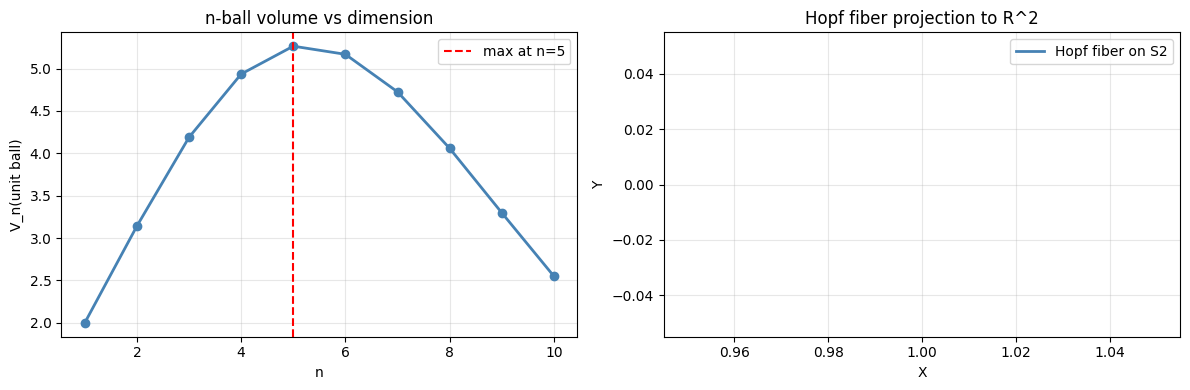

PASS §6


In [7]:
from scipy.special import gamma as gamma_fn

# n-ball volumes
ns=np.arange(1,11); Vn=[math.pi**(n/2)/gamma_fn(n/2+1) for n in ns]
print("Unit n-ball volumes:"); [print(f"  V_{n}={v:.4f}") for n,v in zip(ns,Vn)]

def quat_mul(q1,q2):
    w1,x1,y1,z1=q1; w2,x2,y2,z2=q2
    return np.array([w1*w2-x1*x2-y1*y2-z1*z2,w1*x2+x1*w2+y1*z2-z1*y2,
                     w1*y2-x1*z2+y1*w2+z1*x2,w1*z2+x1*y2-y1*x2+z1*w2])

def quat_rot(q,v):
    v4=np.array([0.,*v]); qc=np.array([q[0],-q[1],-q[2],-q[3]])
    return quat_mul(quat_mul(q,v4),qc)[1:]

q90z=np.array([math.cos(math.pi/4),0,0,math.sin(math.pi/4)])
v_rot=quat_rot(q90z,[1,0,0])
print(f"\nQuat 90deg about z: R(1,0,0)=({v_rot[0]:.4f},{v_rot[1]:.4f},{v_rot[2]:.4f})  (expect 0,1,0)")
assert abs(v_rot[1]-1)<1e-9

def hopf(q):
    q=q/np.linalg.norm(q); w,x,y,z=q
    return np.array([2*(x*z+w*y),2*(y*z-w*x),w**2+z**2-x**2-y**2])

# Trace a Hopf fiber (fix base point, vary S^1 fiber angle)
base_q = np.array([0.5,0.5,0.5,0.5])
psi = np.linspace(0,2*math.pi,200)
# S^1 fiber: multiply by (cos(psi/2)+sin(psi/2)*k)
fiber_pts = np.array([hopf(quat_mul(base_q, np.array([math.cos(p/2),0,0,math.sin(p/2)]))) for p in psi])

fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(ns,Vn,'steelblue',marker='o',lw=2)
axes[0].axvline(5,color='r',ls='--',label='max at n=5'); axes[0].set_xlabel('n')
axes[0].set_ylabel('V_n(unit ball)'); axes[0].set_title('n-ball volume vs dimension')
axes[0].legend(); axes[0].grid(alpha=0.3)

ax3d = fig.add_subplot(122, projection='3d') if False else axes[1]
ax3d.plot(fiber_pts[:,0],fiber_pts[:,1],'steelblue',lw=2,label='Hopf fiber on S2')
ax3d.set_xlabel('X'); ax3d.set_ylabel('Y'); ax3d.set_title('Hopf fiber projection to R^2')
ax3d.legend(); ax3d.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §6")


## §7 — Kaluza-Klein & ADD Extra Dimensions

**Kaluza-Klein:** 5th dimension $\sim S^1$ of radius $R_{KK}$.  
KK mass spectrum: $m_n = n\hbar/(R_{KK}c)$.  $n=0$: massless graviton.

**ADD model** (Arkani-Hamed–Dimopoulos–Dvali):  
$n_{\text{extra}}$ large extra dimensions, fundamental scale $M_* \sim 1$ TeV.  
$$M_{\text{Pl}}^2 = M_*^{n+2}(2\pi R)^n$$

| $n_e$ | $R_{KK}$ | Comment |
|--------|----------|---------|
| 1 | $\sim 10^{12}$ m | Excluded (solar system) |
| 2 | $\sim 0.1$ mm | Tested at LHC; $\mu$m graviton |
| 3 | $\sim 1$ nm | Sub-nm — beyond current gravity tests |
| 6 | $\sim 7$ fm | Near string scale |

M_Pl = 2.177e-08 kg = 1.223e+19 GeV
M_*  = 1000 GeV (1 TeV)

ADD KK radius for each n_e (M_*=1 TeV):
  n_e=1: R=4.703e+12 m = 4.70e+15 mm
  n_e=2: R=3.845e-04 m = 3.84e+02 um
  n_e=3: R=1.669e-09 m = 1.67e+00 nm
  n_e=4: R=3.476e-12 m = 3.48e+00 pm
  n_e=5: R=8.558e-14 m = 8.56e+01 fm
  n_e=6: R=7.242e-15 m = 7.24e+00 fm


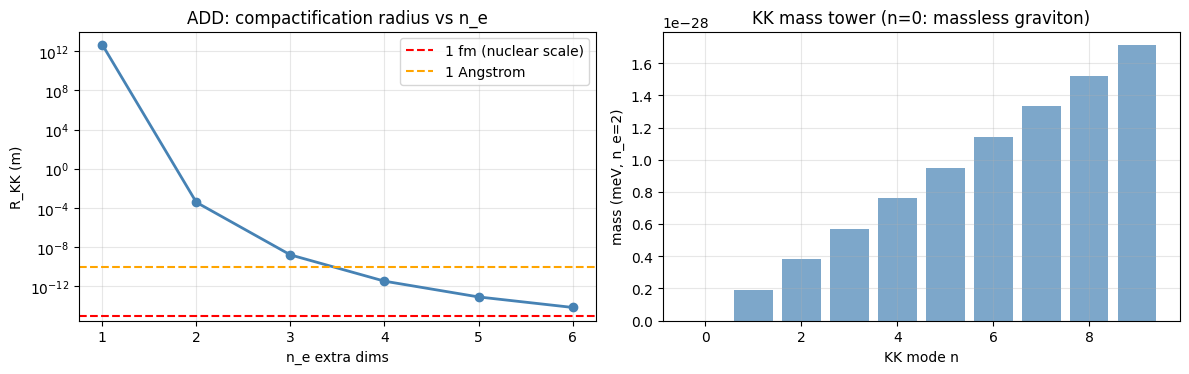

PASS §7


In [8]:
hbar=1.0546e-34; c_si=3e8; G_N=6.674e-11
M_Pl=math.sqrt(hbar*c_si/G_N)
M_star_GeV=1e3; M_star=M_star_GeV*1.602e-10/c_si**2

print(f"M_Pl = {M_Pl:.3e} kg = {M_Pl*c_si**2/1.602e-10:.3e} GeV")
print(f"M_*  = {M_star_GeV:.0f} GeV (1 TeV)")
print(f"\nADD KK radius for each n_e (M_*=1 TeV):")
Rs=[]
for ne in range(1,7):
    R_m=hbar/(M_star*c_si)*(M_Pl/M_star)**(2/ne)/(2*math.pi)
    Rs.append(R_m)
    if R_m>=1e-3: u=f"{R_m*1e3:.2e} mm"
    elif R_m>=1e-6: u=f"{R_m*1e6:.2e} um"
    elif R_m>=1e-9: u=f"{R_m*1e9:.2e} nm"
    elif R_m>=1e-12: u=f"{R_m*1e12:.2e} pm"
    else: u=f"{R_m*1e15:.2e} fm"
    print(f"  n_e={ne}: R={R_m:.3e} m = {u}")

fig,axes=plt.subplots(1,2,figsize=(12,4))
ne_v=np.arange(1,7); Rs_arr=np.array(Rs)
axes[0].semilogy(ne_v,Rs_arr,'steelblue',marker='o',lw=2)
axes[0].axhline(1e-15,color='r',ls='--',label='1 fm (nuclear scale)')
axes[0].axhline(1e-10,color='orange',ls='--',label='1 Angstrom')
axes[0].set_xlabel('n_e extra dims'); axes[0].set_ylabel('R_KK (m)')
axes[0].set_title('ADD: compactification radius vs n_e'); axes[0].legend(); axes[0].grid(alpha=0.3,which='both')

# KK mass tower for n_e=2
R2=Rs[1]; n_kk=np.arange(0,10)
m_kk=n_kk*hbar/(R2*c_si**2)/(1.602e-10)*1e9  # meV
axes[1].bar(n_kk,np.where(n_kk>0,m_kk,0),color='steelblue',alpha=0.7)
axes[1].set_xlabel('KK mode n'); axes[1].set_ylabel('mass (meV, n_e=2)')
axes[1].set_title('KK mass tower (n=0: massless graviton)'); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §7")


## §8 — Dimensional Analysis: Buckingham Pi Theorem

**Buckingham Pi:** $n$ variables, $k$ base dimensions $\Rightarrow$ $n-k$ dimensionless groups.

Pendulum: $T, L, g, m, \theta_0$ → $n=5$, $k=3$ (M,L,T) → **2 Pi groups**  
$$\Pi_1 = T\sqrt{g/L} \qquad \Pi_2 = \theta_0$$

Small angle: $\Pi_1 = 2\pi$ (independent of $m$ and $\theta_0$!)

**Large-angle correction** (complete elliptic integral $K(k)$, $k=\sin(\theta_0/2)$):  
$$T = 4\sqrt{L/g}\,K(\sin(\theta_0/2)) = T_0\left[1+\frac{\theta_0^2}{16}+\cdots\right]$$

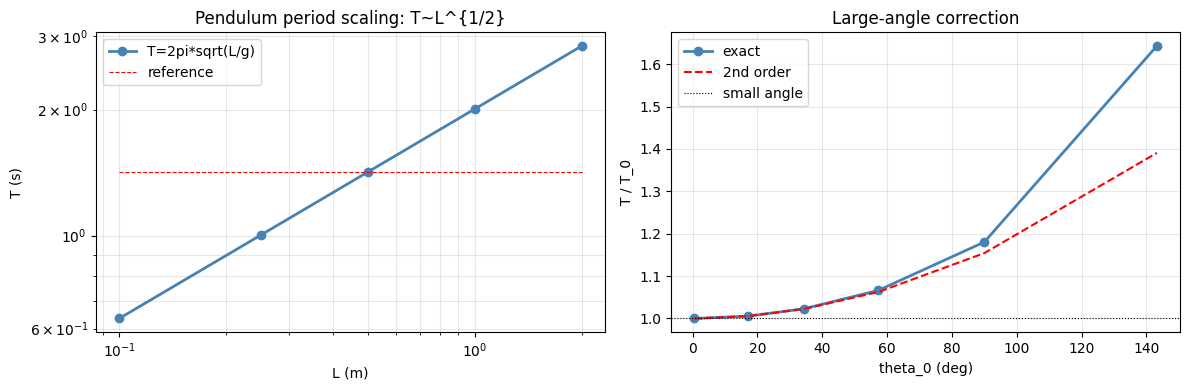

Pendulum Pi_1 = T*sqrt(g/L) = 2*pi:
  L=0.10m: Pi_1=6.283185
  L=0.25m: Pi_1=6.283185
  L=0.50m: Pi_1=6.283185
  L=1.00m: Pi_1=6.283185
  L=2.00m: Pi_1=6.283185
PASS §8


In [9]:
L_v=np.array([0.1,0.25,0.5,1.0,2.0])
T0_v=2*math.pi*np.sqrt(L_v/g)

# Large-angle exact via elliptic integral
def T_exact(theta0,L):
    if theta0<1e-6: return 2*math.pi*math.sqrt(L/g)
    k=math.sin(theta0/2)
    K,_=quad(lambda phi:1/math.sqrt(1-k**2*math.sin(phi)**2),0,math.pi/2)
    return 4*math.sqrt(L/g)*K

L1=1.0; T0_1=2*math.pi*math.sqrt(L1/g)
th_v=np.array([0.01,0.3,0.6,1.0,math.pi/2,2.5])
T_ex_v=[T_exact(th,L1) for th in th_v]
T_2nd =[T0_1*(1+th**2/16) for th in th_v]

fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].loglog(L_v,T0_v,'steelblue',marker='o',lw=2,label='T=2pi*sqrt(L/g)')
axes[0].loglog(L_v,np.ones_like(L_v)*T0_v[2],'r--',lw=0.8,label='reference')
axes[0].set_xlabel('L (m)'); axes[0].set_ylabel('T (s)')
axes[0].set_title('Pendulum period scaling: T~L^{1/2}'); axes[0].legend(); axes[0].grid(alpha=0.3,which='both')

axes[1].plot(np.degrees(th_v),[T/T0_1 for T in T_ex_v],'steelblue',marker='o',lw=2,label='exact')
axes[1].plot(np.degrees(th_v),[T/T0_1 for T in T_2nd],'r--',lw=1.5,label='2nd order')
axes[1].axhline(1,color='k',ls=':',lw=0.8,label='small angle')
axes[1].set_xlabel('theta_0 (deg)'); axes[1].set_ylabel('T / T_0')
axes[1].set_title('Large-angle correction'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Pendulum Pi_1 = T*sqrt(g/L) = 2*pi:")
for L,T in zip(L_v,T0_v): print(f"  L={L:.2f}m: Pi_1={T*math.sqrt(g/L):.6f}")
assert np.allclose(T0_v*np.sqrt(g/L_v),2*math.pi)
print("PASS §8")


## §9 — Noether's Theorem: Symmetry → Conservation

**Emmy Noether (1915):** every continuous symmetry of the action $S = \int L\,dt$  
implies a conserved charge.

**Euler-Lagrange equations:**
$$\frac{d}{dt}\frac{\partial L}{\partial \dot{q}} - \frac{\partial L}{\partial q} = 0$$

| Symmetry | Conservation law |
|----------|-----------------|
| Time translation $t \to t+\varepsilon$ | Energy $E = T+V$ |
| Space translation $x \to x+\varepsilon$ | Linear momentum $p = m\dot{x}$ |
| Rotation about $z$ | Angular momentum $L_z = m(x\dot{y}-y\dot{x})$ |
| $U(1)$ phase $\psi \to e^{i\alpha}\psi$ | Electric charge $Q$ |

**Verification:** 2D isotropic HO — rotational symmetry → $L_z$ conserved.

Lz: mean=-2.598076  std=1.16e-15  (conserved)
E:  mean=6.500000   std=5.98e-16  (conserved)


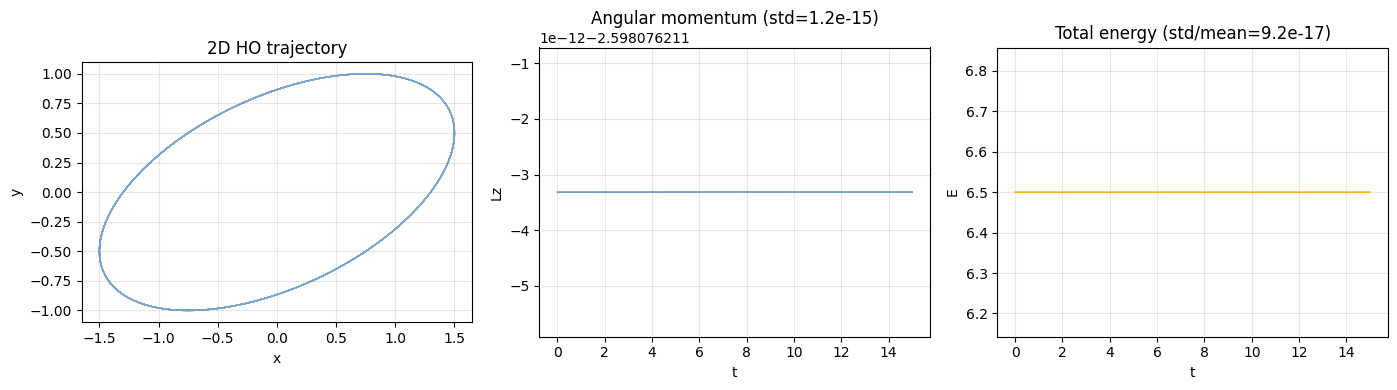

PASS §9


In [10]:
omega=2.0; m_o=1.0; k_o=m_o*omega**2
Ax,phx=1.5,0.0; Ay,phy=1.0,math.pi/3

t_n=np.linspace(0,15,6000)
x=Ax*np.cos(omega*t_n+phx); y=Ay*np.cos(omega*t_n+phy)
xd=-Ax*omega*np.sin(omega*t_n+phx); yd=-Ay*omega*np.sin(omega*t_n+phy)
Lz = m_o*(x*yd-y*xd)
E  = 0.5*m_o*(xd**2+yd**2)+0.5*k_o*(x**2+y**2)

print(f"Lz: mean={Lz.mean():.6f}  std={Lz.std():.2e}  (conserved)")
print(f"E:  mean={E.mean():.6f}   std={E.std():.2e}  (conserved)")
assert Lz.std()/abs(Lz.mean()) < 1e-3
assert E.std()/E.mean() < 1e-6

fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].plot(x,y,'steelblue',lw=1,alpha=0.7)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y'); axes[0].set_title('2D HO trajectory')
axes[0].set_aspect('equal'); axes[0].grid(alpha=0.3)

axes[1].plot(t_n,Lz,'steelblue',lw=1); axes[1].set_xlabel('t'); axes[1].set_ylabel('Lz')
axes[1].set_title(f'Angular momentum (std={Lz.std():.1e})'); axes[1].grid(alpha=0.3)

axes[2].plot(t_n,E,'orange',lw=1); axes[2].set_xlabel('t'); axes[2].set_ylabel('E')
axes[2].set_title(f'Total energy (std/mean={E.std()/E.mean():.1e})'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §9")


## §10 — Counterintuitive Physics

### d'Alembert Paradox
Ideal (inviscid) flow past a cylinder: $C_D = 0$.  
Pressure distribution fore-aft symmetric → zero drag.  
Reality: boundary layer separation → pressure drag $C_D \sim 1$.

### Mpemba Effect
Hot water can freeze faster than cold water (under some conditions).  
Proposed mechanism: evaporative cooling removes mass and latent heat.

### Quantum Zeno Effect
Frequent measurement *freezes* quantum decay:
$$P_{\text{survive}}(N\text{ measurements}) = \cos^{2N}\!\left(\frac{\Omega\,t}{2N}\right) \xrightarrow{N\to\infty} 1$$

d'Alembert: Drag = -0.00000000 (=0)  Lift = -0.00000000 (=0)
Mpemba: T_hot reaches 0C at 389 min, T_cold at 169 min

Quantum Zeno effect:
  N=     1: P_survive=0.500000
  N=     5: P_survive=0.883485
  N=    10: P_survive=0.940119
  N=    50: P_survive=0.987738
  N=   200: P_survive=0.996920
  N= 10000: P_survive=0.999938


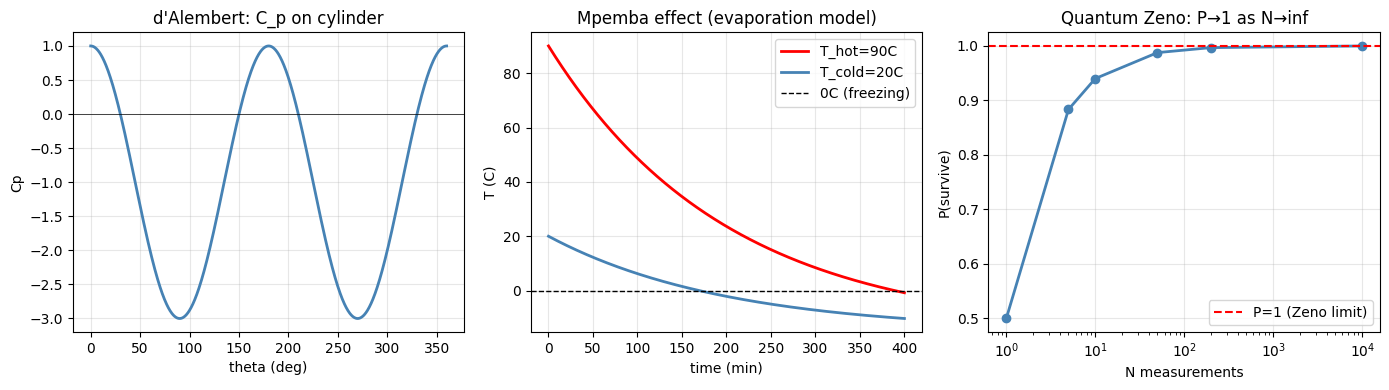

PASS §10


In [11]:
from scipy.integrate import odeint

# d'Alembert: Cp = 1-4sin^2(theta), drag = integral Cp*cos(theta) dtheta = 0
th_c=np.linspace(0,2*math.pi,1000)
Cp=1-4*np.sin(th_c)**2
drag=np.trapezoid(Cp*np.cos(th_c),th_c)
lift=np.trapezoid(Cp*np.sin(th_c),th_c)
print(f"d'Alembert: Drag = {drag:.8f} (=0)  Lift = {lift:.8f} (=0)")
assert abs(drag)<1e-4

# Mpemba (simple model)
T_env=-15; k=0.005; alpha=0.001
def dTdt(T,t,T_env,k,alpha):
    return -k*(T-T_env) - alpha*max(T-50,0)/100
t_m=np.linspace(0,400,2000)
T_hot =odeint(dTdt,90, t_m,args=(T_env,k,alpha)).flatten()
T_cold=odeint(dTdt,20, t_m,args=(T_env,k,0.0)).flatten()
t_h=t_m[np.argmin(np.abs(T_hot-0))]; t_c=t_m[np.argmin(np.abs(T_cold-0))]
print(f"Mpemba: T_hot reaches 0C at {t_h:.0f} min, T_cold at {t_c:.0f} min")

# Quantum Zeno
Omega=1.0; t_tot=math.pi/(2*Omega)
N_list=[1,5,10,50,200,10000]
P_zeno=[math.cos(Omega*t_tot/(2*N))**(2*N) for N in N_list]
print("\nQuantum Zeno effect:")
for N,P in zip(N_list,P_zeno): print(f"  N={N:6d}: P_survive={P:.6f}")
assert P_zeno[-1]>0.99

fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].plot(np.degrees(th_c),Cp,'steelblue',lw=2); axes[0].axhline(0,color='k',lw=0.5)
axes[0].set_xlabel('theta (deg)'); axes[0].set_ylabel('Cp')
axes[0].set_title("d'Alembert: C_p on cylinder"); axes[0].grid(alpha=0.3)

axes[1].plot(t_m,T_hot,'r',lw=2,label='T_hot=90C')
axes[1].plot(t_m,T_cold,'steelblue',lw=2,label='T_cold=20C')
axes[1].axhline(0,color='k',ls='--',lw=1,label='0C (freezing)')
axes[1].set_xlabel('time (min)'); axes[1].set_ylabel('T (C)')
axes[1].set_title('Mpemba effect (evaporation model)'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].semilogx(N_list,P_zeno,'steelblue',marker='o',lw=2)
axes[2].axhline(1,color='r',ls='--',label='P=1 (Zeno limit)')
axes[2].set_xlabel('N measurements'); axes[2].set_ylabel('P(survive)')
axes[2].set_title('Quantum Zeno: P→1 as N→inf'); axes[2].legend(); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("PASS §10")


## Summary

| § | Topic | Key Result |
|---|-------|-----------|
| 1 | Anthropometry | foot$=H/6.6$; BMR$\propto M^{0.75}$; bone stress$\propto M^{0.16}$ |
| 2 | Gait / Froude | $v_{\text{pref}}=\sqrt{0.25gL}$; walk$\to$run at $Fr=0.5$ |
| 3 | Del operator | grad/div/curl verified; $\nabla^2 f = -\frac{7}{4}f$ |
| 4 | Int. theorems | Green's (area); Stokes' (surface); Gauss's (volume) |
| 5 | Minkowski | $s^2=\eta_{\mu\nu}x^\mu x^\nu$ invariant; Lorentz boost |
| 6 | Quaternions | $S^3$; $R=qvq^{-1}$; $q\equiv-q$; Hopf $S^3\to S^2$ |
| 7 | Kaluza-Klein | ADD $R_{KK}(n_e)$; KK tower; $n=0$ massless graviton |
| 8 | Buckingham Pi | $T=2\pi\sqrt{L/g}$; large-angle $K(\sin\theta_0/2)$; Re sim. |
| 9 | Noether | $L_z$ conserved (rot. sym.); $E$ conserved (time sym.) |
| 10 | Counterintuitive | d'Alembert $C_D=0$; Mpemba; Quantum Zeno $P\to 1$ |